In [112]:
import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [187]:
#gdp data


gdp = pd.read_csv('world_gdp_data.csv', encoding='latin-1')


gdp.columns = gdp.columns.astype(str).str.strip().str.replace('.0', '', regex = False)

gdp_year_cols = [str(c) for c in gdp.columns if str(c).isdigit()]

gdp_series = gdp[gdp_year_cols].apply(pd.to_numeric, errors='coerce')
gdp_growth = pd.DataFrame(gdp_series).fillna(0)



#cpi data

cpi = pd.read_csv('cpiai_csv.csv', encoding='latin-1')


cpi['Date'] = pd.to_datetime(cpi['Date'])
cpi['Year'] = cpi['Date'].astype(str).str[:4]


cpi.columns = cpi.columns.str.strip()
cpi_series = cpi.set_index('Date')['Index']

cpi_series.index = cpi_series.index.astype(str)
cpi_year_cols = cpi_series.index.tolist()
cpi_yearly = cpi.groupby('Year')['Index'].mean()
cpi_yearly.index = cpi_yearly.index.astype(str)
cpi_inflation = pd.DataFrame(cpi_series).fillna(0)

years = sorted(set(gdp_year_cols) & set(cpi_yearly.index))




#align

                                            
gdpAligned = gdp_series.mean(axis=0).loc[years]
cpiAligned = cpi_yearly.loc[years]


# volatility
volatility = gdpAligned.pct_change().rolling(3, min_periods=1).std().fillna(0)

# build dataset
data = pd.DataFrame({
    'GDP': gdpAligned.values,
    'GDP_Growth': gdpAligned.pct_change().fillna(0).values,
    'CPI_Inflation': cpiAligned.pct_change().fillna(0).values,
    'Volatility': volatility.values
}, index=years)


# target = whether next year's GDP growth is positive
future_growth = data['GDP_Growth'].shift(-1)
data['Target'] = (future_growth > 0).astype(int)

# remove last row (no future value)
data = data[:-1]

# normalization
features = ['GDP', 'GDP_Growth', 'CPI_Inflation', 'Volatility']

scaler = StandardScaler()


X = scaler.fit_transform(data[features])
y = data['Target']


print(data)


(34, 4)
(34,)
           GDP  GDP_Growth  CPI_Inflation  Volatility  Target
1980  3.113475    0.000000       0.000000    0.000000       0
1981  2.677931   -0.139890       0.103347    0.000000       0
1982  1.320408   -0.506930       0.061314    0.259536       1
1983  1.832653    0.387944       0.032124    0.449838       1
1984  4.196599    1.289903       0.043005    0.898419       0
1985  3.125170   -0.255309       0.035456    0.776207       1
1986  3.728378    0.193016       0.018980    0.794967       0
1987  3.718792   -0.002571       0.036646    0.224769       1
1988  4.114000    0.106273       0.040777    0.098002       0
1989  3.396667   -0.174364       0.048270    0.141490       0
1990  2.804000   -0.174485       0.053980    0.162061       0
1991  1.955063   -0.302759       0.042350    0.074094       1
1992  2.851250    0.458393       0.030288    0.407501       0
1993  1.726316   -0.394541       0.029517    0.468201       1
1994  2.186705    0.266689       0.026074    0.447488   

In [195]:
# model 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

#setting variables

weights = np.array([0.35, 0.25, -0.20, -0.20])
score = np.dot(X, weights)

mm = MinMaxScaler(feature_range=(-1, 1))
market_signal = mm.fit_transform(score.reshape(-1, 1)).flatten()
market_signal = mm.fit_transform(score.reshape(-1, 1)).flatten()

plt.figure(figsize=(16, 9))
plt.plot(data.index, market_signal, linewidth=3, marker='o')
plt.axhline(0, linestyle='--')
plt.fill_between(data.index, market_signal, alpha=0.2)

plt.title('Market Sentiment Composite Indicator', fontsize=22, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Signal Strength (-1 to 1)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

for i, val in enumerate(market_signal):
    plt.text(data.index[i], val + 0.03, f'{val:.2f}', ha='center')

plt.tight_layout()
plt.show()



              precision    recall  f1-score   support

           0       0.60      0.75      0.67         4
           1       0.50      0.33      0.40         3

    accuracy                           0.57         7
   macro avg       0.55      0.54      0.53         7
weighted avg       0.56      0.57      0.55         7



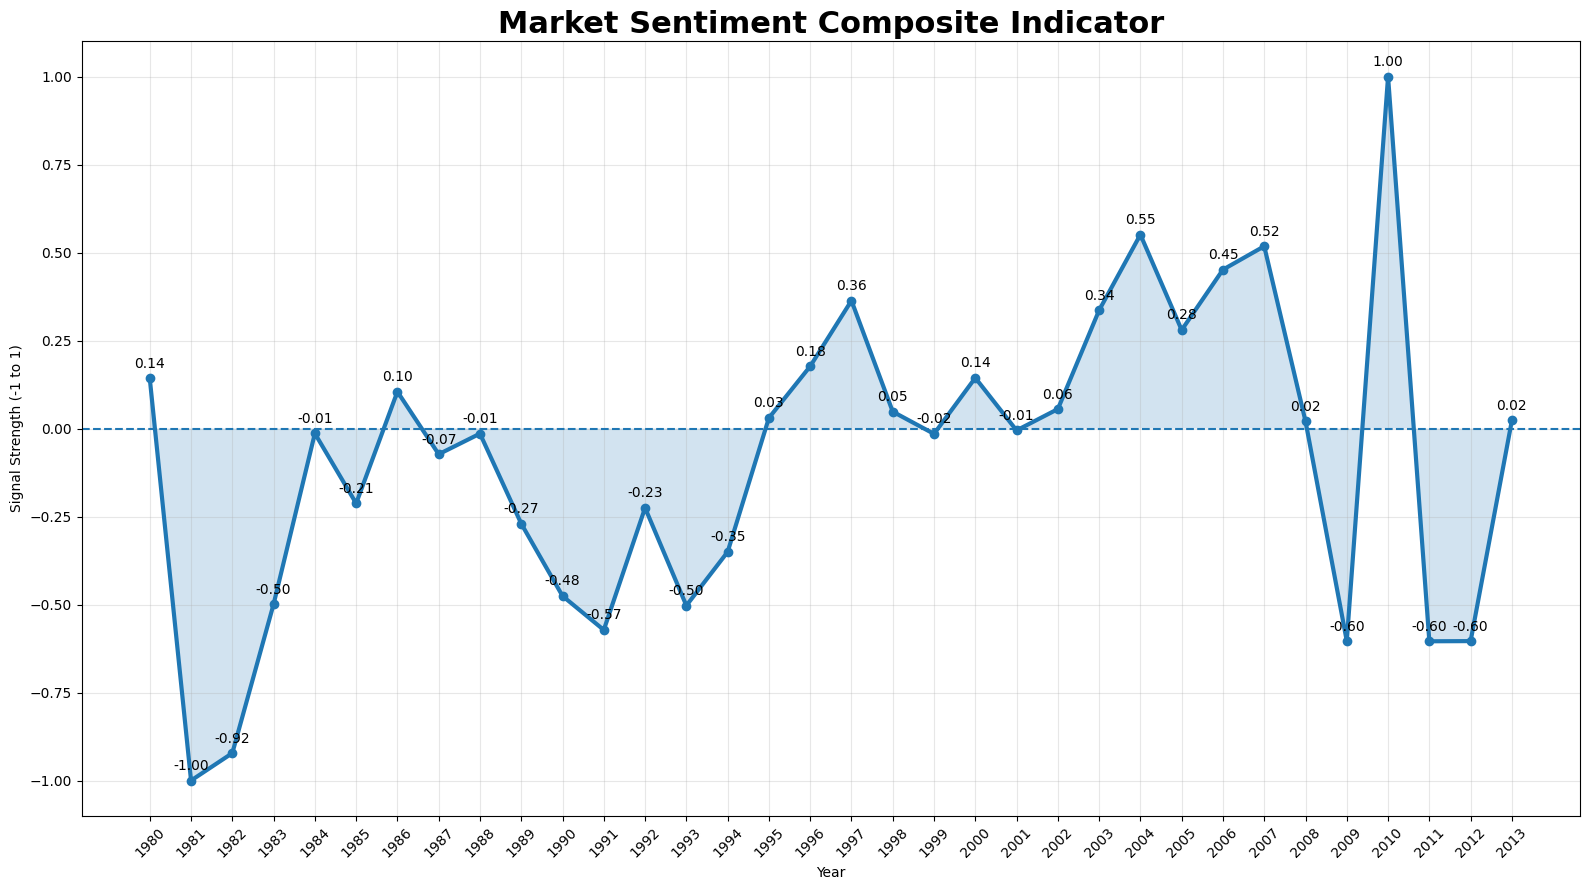

In [203]:
market_signal = mm.fit_transform(score.reshape(-1, 1)).flatten()

plt.figure(figsize=(16, 9))
plt.plot(data.index, market_signal, linewidth=3, marker='o')
plt.axhline(0, linestyle='--')
plt.fill_between(data.index, market_signal, alpha=0.2)

plt.title('Market Sentiment Composite Indicator', fontsize=22, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Signal Strength (-1 to 1)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

for i, val in enumerate(market_signal):
    plt.text(data.index[i], val + 0.03, f'{val:.2f}', ha='center')

plt.tight_layout()
plt.show()

In [186]:
# results

print('\nINTERPRETATION:')
print('Positive -> Favorable investment climate')
print('Negative -> Caution / elevated macroeconomic risk')


INTERPRETATION:
Positive -> Favorable investment climate
Negative -> Caution / elevated macroeconomic risk
